# C01 – Traffic Count Prediction by Site

End-to-end notebook: feature engineering → LightGBM training → per-site evaluation → site-level prediction.

**Target**: hourly cyclist count () per  and direction (/).

In [ ]:
%load_ext autoreload
%autoreload 2

import sys, os, warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.join(os.path.dirname("__file__"), "lib"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

pd.options.display.max_columns = 50
pd.options.display.float_format = "{:.2f}".format
sns.set_theme(style="whitegrid", palette="muted")

from hahelper import *
from features import *
from model import *


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Configuration

In [69]:
BASE      = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()

PATH_LABEL           = os.path.join(BASE, "feature", "label_hourly_201908_202603.csv")
PATH_FTS_TRAFFIC     = os.path.join(BASE, "feature", "fts_traffic_agg15min.csv")
PATH_FTS_DATETIME    = os.path.join(BASE, "feature", "fts_datetime.csv")
PATH_FTS_SITES       = os.path.join(BASE, "feature", "fts_site.csv")
PATH_FTS_WEATHER     = os.path.join(BASE, "feature", "fts_weather.csv")
PATH_FTS_POPULATION  = os.path.join(BASE, "feature", "fts_population.csv")

# PATH_MODEL      = os.path.join(BASE, "models", "lgbm_traffic.txt")
# os.makedirs(os.path.join(BASE, "models"), exist_ok=True)


print(f"Fts Traffic  : {PATH_FTS_TRAFFIC}")
print(f"Fts Datetime : {PATH_FTS_DATETIME}")
print(f"Fts Site     : {PATH_FTS_SITES}")
print(f"Fts Weather  : {PATH_FTS_WEATHER}")
print(f"Fts Pop      : {PATH_FTS_POPULATION}")


Fts Traffic  : /Users/ponddie/Documents/py/mda_project/explo/yenha/feature/fts_traffic_agg15min.csv
Fts Datetime : /Users/ponddie/Documents/py/mda_project/explo/yenha/feature/fts_datetime.csv
Fts Site     : /Users/ponddie/Documents/py/mda_project/explo/yenha/feature/fts_site.csv
Fts Weather  : /Users/ponddie/Documents/py/mda_project/explo/yenha/feature/fts_weather.csv
Fts Pop      : /Users/ponddie/Documents/py/mda_project/explo/yenha/feature/fts_population.csv


## 2. Build Feature Dataset

This step loads all monthly traffic files (~45 months from 6/2022 to 2/2026), aggregates to hourly, then joins weather, population, and time features.

In [70]:
df_label = pd.read_csv(PATH_LABEL).query("datehour>='2022-06' and datehour<'2026-03'")
df_fts_traffic    = pd.read_csv(PATH_FTS_TRAFFIC).drop(columns=['traffic_in','traffic_out'])
df_fts_datetime   = pd.read_csv(PATH_FTS_DATETIME).drop(columns=['dt_public_holiday'])
df_fts_sites      = pd.read_csv(PATH_FTS_SITES)
df_fts_population = pd.read_csv(PATH_FTS_POPULATION)[['site_id', 'pop_1km', 'pop_5km', 'pop_10km']]
df_fts_weather    = pd.read_csv(PATH_FTS_WEATHER)
df_fts_weather['datehour'] = pd.to_datetime(df_fts_weather["datetime"]).dt.strftime('%Y-%m-%d %H:%M:%S')
df_fts_weather = df_fts_weather[['site_id', 'datehour', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'wind_direction_10m', 'pressure_msl', 'cloud_cover']]
df_fts_weather = df_fts_weather.rename(columns={x: f"wt_{x}" for x in df_fts_weather.columns if x not in ['site_id','datehour']})
df_label.shape, df_fts_traffic.shape, df_fts_datetime.shape, df_fts_sites.shape, df_fts_population.shape, df_fts_weather.shape

KeyboardInterrupt: 

In [ ]:
dfxy = (
    df_label
    .merge(df_fts_traffic, on=['site_id', 'datehour'], how='left')
    .merge(df_fts_datetime, on=['site_id', 'datehour'], how='left')
    .merge(df_fts_sites, on=['site_id', 'datehour'], how='left')
    .merge(df_fts_population, on=['site_id'], how='left')
    .merge(df_fts_weather, on=['site_id', 'datehour'], how='left')
    )
print(dfxy.shape)
print(f"Date range : {dfxy['date'].min()}, {dfxy['date'].max()}")
dfxy.head(3)

(4447687, 53)
Date range : 1, 31


,site_id,datehour,year,month,date,hour,traffic_in,traffic_out,traffic_total,traffic_in_00_15,traffic_out_00_15,traffic_in_15_30,traffic_out_15_30,traffic_in_30_45,traffic_out_30_45,traffic_in_45_60,traffic_out_45_60,traffic_in_15m_mean,traffic_in_15m_std,traffic_in_15m_min,traffic_in_15m_max,traffic_out_15m_mean,traffic_out_15m_std,traffic_out_15m_min,traffic_out_15m_max,...,dt_is_friday,dt_is_morning_rush,dt_is_afternoon_rush,dt_is_rush_hour,dt_is_lunch_hour,dt_is_night,dt_is_business_hours,dt_is_public_holiday,site_sensor_age,site_is_road_tunnel,site_is_road_national,site_is_road_ring,site_is_road_motorway,pop_1km,pop_5km,pop_10km,wt_temperature_2m,wt_relative_humidity_2m,wt_precipitation,wt_rain,wt_snowfall,wt_wind_speed_10m,wt_wind_direction_10m,wt_pressure_msl,wt_cloud_cover
0,1,2022-06-01 00:00:00,2022,6,1,0,0.00,2.00,2.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.50,0.58,0.00,1.00,...,0,0,0,0,0,1,0,0,1014,1,0,0,0,2754.79,99128.39,726663.75,8.60,91,0.00,0.00,0.00,6.70,196,1014.30,2
1,1,2022-06-01 01:00:00,2022,6,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0,0,0,0,0,1,0,0,1014,1,0,0,0,2754.79,99128.39,726663.75,9.10,85,0.00,0.00,0.00,11.40,242,1014.90,9
2,1,2022-06-01 02:00:00,2022,6,1,2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0,0,0,0,0,1,0,0,1014,1,0,0,0,2754.79,99128.39,726663.75,8.60,86,0.00,0.00,0.00,9.20,239,1014.80,8


In [ ]:
dfxy.select_dtypes(include=['object', 'category']).columns.tolist()

['datehour']

In [ ]:
dfxy.to_csv('data/training_48fts.csv', index=False)

## 3. Prepare tvt

In [ ]:
dfxy = pd.read_csv('data/training_48fts.csv')

In [ ]:
# fts_traffic = [x for x in dfxy if x.startswith('traffic') and x not in ['traffic_in','traffic_out','traffic_total']]
fts_datetime = [x for x in dfxy if x.startswith('dt')]
fts_site = [x for x in dfxy if x.startswith('site') if x!='site_id']
fts_pop = [x for x in dfxy if x.startswith('pop')]
fts_wt = [x for x in dfxy if x.startswith('wt')]

print("fts_traffic:", len(fts_traffic)),
print("fts_datetime:", len(fts_datetime)),
print("fts_site:", len(fts_site)),
print("fts_pop:", len(fts_pop)),
print("fts_wt:", len(fts_wt)),

FEATURE_COLS = fts_datetime+fts_site+fts_pop+fts_wt#+fts_traffic
TARGET = "traffic_total"
print(' => N features:',len(FEATURE_COLS))
print('metadata', [x for x in dfxy if x not in FEATURE_COLS and x not in TARGET])


fts_traffic: 16
fts_datetime: 11
fts_site: 5
fts_pop: 3
fts_wt: 9
 => N features: 28
metadata ['site_id', 'datehour', 'year', 'month', 'date', 'hour', 'traffic_in', 'traffic_out', 'traffic_in_00_15', 'traffic_out_00_15', 'traffic_in_15_30', 'traffic_out_15_30', 'traffic_in_30_45', 'traffic_out_30_45', 'traffic_in_45_60', 'traffic_out_45_60', 'traffic_in_15m_mean', 'traffic_in_15m_std', 'traffic_in_15m_min', 'traffic_in_15m_max', 'traffic_out_15m_mean', 'traffic_out_15m_std', 'traffic_out_15m_min', 'traffic_out_15m_max']


In [ ]:
dfxy = dfxy.query("datehour>='2025-01' and datehour<'2026-03'")
dfxy.shape

cutoff = '2025-12'
df_train = dfxy[dfxy["datehour"] <= cutoff].copy()
df_test  = dfxy[dfxy["datehour"] > cutoff].copy()
print(f"Train {df_train.shape}: {df_train['datehour'].min()}, {df_train['datehour'].max()}")
print(f"Test   {df_test.shape}: {df_test['datehour'].min()}, {df_test['datehour'].max()}")
print("Test fraction:", len(df_test)/(len(df_train)+len(df_test)))

X_train, y_train = split_traintest(df_train, list_features=FEATURE_COLS, target=TARGET)
X_test, y_test = split_traintest(df_test, list_features=FEATURE_COLS, target=TARGET)

Train (1129295, 53): 2025-01-01 00:00:00, 2025-11-30 23:00:00
Test   (313200, 53): 2025-12-01 00:00:00, 2026-02-28 23:00:00
Test fraction: 0.21712380285546917


## 4. Training

In [74]:
import time
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

dm_reg = {
    "LinearRegression": LinearRegression(n_jobs=-1, fit_intercept=True),
    "DecisionTree": DecisionTreeRegressor(
        max_depth=12,
        min_samples_leaf=50,
        random_state=42,
    ),
    "RandomForest": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        min_samples_leaf=5,
        subsample=0.8,
        random_state=42,
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        min_samples_leaf=20,
        subsample=0.8,
        random_state=42,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        # No early stopping as no valid set
    ),
}

dmodels = {}
for name, model in dm_reg.items():
    start_time = time.time()

    if name == "LinearRegression":
        X_tr, X_te = X_train.fillna(0), X_test.fillna(0)
    else:
        X_tr, X_te = X_train, X_test

    model.fit(X_tr, y_train)
    dmodels[f"model_{name}"] = model

    pred_train = model.predict(X_tr)
    pred_test = model.predict(X_te)

    mae_train = mean_absolute_error(y_train, pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
    mae_test = mean_absolute_error(y_test, pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

    print(
        f"{name:18s} | test: MAE={mae_test:.3f}  RMSE={rmse_test:.3f} "
        f"| train: MAE={mae_train:.3f}  RMSE={rmse_train:.3f} "
        f"| train_time: {(time.time() - start_time):.5f}"
    )

LinearRegression   | test: MAE=18.083  RMSE=33.334 | train: MAE=21.187  RMSE=41.744 | train_time: 0.64786
DecisionTree       | test: MAE=10.004  RMSE=23.552 | train: MAE=10.925  RMSE=23.112 | train_time: 4.37318
RandomForest       | test: MAE=9.011  RMSE=21.200 | train: MAE=9.864  RMSE=21.141 | train_time: 380.79368
GradientBoosting   | test: MAE=9.278  RMSE=21.329 | train: MAE=10.703  RMSE=22.763 | train_time: 320.47642
XGBoost            | test: MAE=8.771  RMSE=20.750 | train: MAE=9.751  RMSE=21.331 | train_time: 6.85694


In [75]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_tuned = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [3, 4, 5],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 1.5, 2.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'random_state': [42],
    'n_jobs': [-1]
}

rs_tuned = RandomizedSearchCV(
    XGBRegressor(),
    param_distributions=param_grid_tuned,
    n_iter=30,
    scoring='neg_mean_absolute_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rs_tuned.fit(X_train, y_train)

tuned_preds = rs_tuned.best_estimator_.predict(X_test)
tuned_mae = mean_absolute_error(y_test, tuned_preds)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_preds))
print(f"Best Params: {rs_tuned.best_params_}")
print(f"MAE: {round(tuned_mae, 2)} - RMSE: {round(tuned_rmse, 2)}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Params: {'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 1.0, 'random_state': 42, 'n_jobs': -1, 'n_estimators': 500, 'min_child_weight': 4, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.7}
MAE: 8.57 - RMSE: 20.46


## 5. Feature Importance

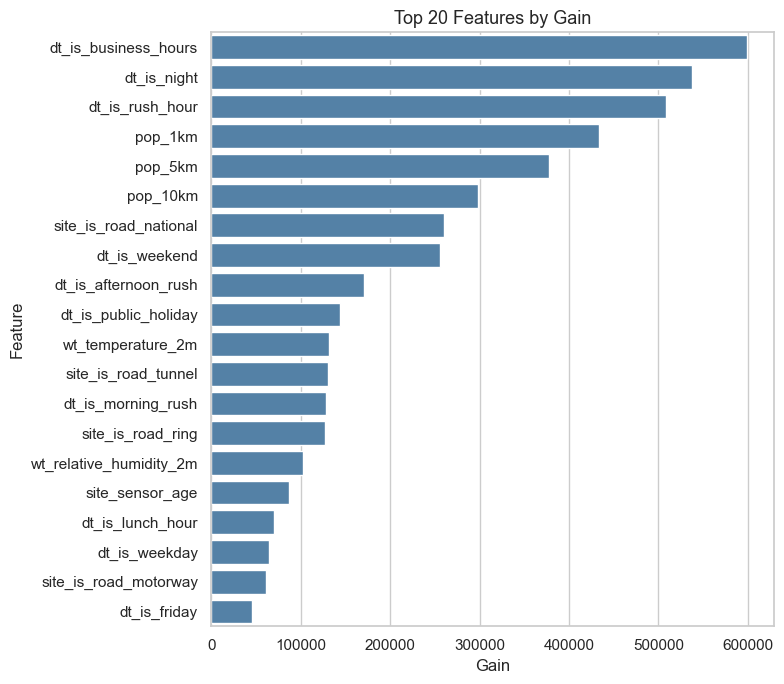

,feature,importance
0,dt_is_business_hours,599290.69
1,dt_is_night,537128.12
2,dt_is_rush_hour,508200.84
3,pop_1km,433148.47
4,pop_5km,377209.19
5,pop_10km,297738.31
6,site_is_road_national,259946.77
7,dt_is_weekend,256223.59
8,dt_is_afternoon_rush,170773.80
9,dt_is_public_holiday,143460.02


In [78]:

df_imp = feature_importance_xgb(rs_tuned.best_estimator_, list(X_train.columns), importance_type="gain")

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(data=df_imp.head(20), x="importance", y="feature", ax=ax, color="steelblue")
ax.set_title("Top 20 Features by Gain", fontsize=13)
ax.set_xlabel("Gain")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

df_imp

## 6. Per-Site Evaluation on Test Set

In [ ]:

metrics = evaluate_by_site(rs_tuned.best_estimator_, X_test, list(X_train.columns))

print(f"Overall test MAE : {metrics['mae'].mean():.2f}")
print(f"Overall test RMSE: {metrics['rmse'].mean():.2f}")
print(f"Median MAPE      : {metrics['mape'].median():.1f} %")
print()
print("Worst 10 sites by MAE:")
metrics.head(10)


KeyError: "Target column 'traffic_total' not found in test set columns: ['dt_is_weekend', 'dt_is_weekday', 'dt_is_monday', 'dt_is_friday', 'dt_is_morning_rush', 'dt_is_afternoon_rush', 'dt_is_rush_hour', 'dt_is_lunch_hour', 'dt_is_night', 'dt_is_business_hours', 'dt_is_public_holiday', 'site_sensor_age', 'site_is_road_tunnel', 'site_is_road_national', 'site_is_road_ring', 'site_is_road_motorway', 'pop_1km', 'pop_5km', 'pop_10km', 'wt_temperature_2m', 'wt_relative_humidity_2m', 'wt_precipitation', 'wt_rain', 'wt_snowfall', 'wt_wind_speed_10m', 'wt_wind_direction_10m', 'wt_pressure_msl', 'wt_cloud_cover']"

In [ ]:
# MAE distribution across sites
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(metrics["mae"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("MAE distribution across sites")
axes[0].set_xlabel("MAE (cyclists / hour)")
axes[0].set_ylabel("Number of sites")

axes[1].scatter(metrics["mean_actual"], metrics["mae"], alpha=0.6, color="coral")
axes[1].set_title("MAE vs mean actual count")
axes[1].set_xlabel("Mean actual count (cyclists / hour)")
axes[1].set_ylabel("MAE")

plt.tight_layout()
plt.show()


## 7. Predict Traffic for a Specific Site

Change , ,  (and optionally ) to get predictions for any site and time window.

In [ ]:
# ── Configuration ──────────────────────────────────────────────
SITE_ID   = 1          # change to any siteid in your dataset
START     = "2025-01-06"
END       = "2025-01-12 23:00"
DIRECTION = None       # 'IN', 'OUT', or None (both)
# ───────────────────────────────────────────────────────────────

df_pred = predict_for_site(
    booster=booster,
    site_id=SITE_ID,
    start_dt=START,
    end_dt=END,
    df_hist=df,
    feature_cols=feat_cols,
    richting=DIRECTION,
)

print(f"Predictions for site {SITE_ID}:")
df_pred.head(10)


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

for ax, (direction, grp) in zip(axes, df_pred.groupby("richting")):
    ax.plot(grp["datetime"], grp["predicted_aantal"],
            label="Predicted", color="steelblue", linewidth=1.5)
    if TARGET_COL in grp.columns:
        ax.plot(grp["datetime"], grp[TARGET_COL],
                label="Actual", color="coral", linewidth=1.5, alpha=0.8)
    ax.set_title(f"Site {SITE_ID} — {direction} direction")
    ax.set_ylabel("Cyclists / hour")
    ax.legend()
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%a
%d %b"))
    plt.setp(ax.xaxis.get_majorticklabels(), fontsize=8)

plt.suptitle(f"Site {SITE_ID}: {START} → {END}", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### Daily summary

In [ ]:
df_daily = predict_daily_summary(booster, SITE_ID, START, END, df, feat_cols)
df_daily


## 8. Compare Multiple Sites on a Single Day

Useful for understanding which sites are busiest at a given hour.

In [ ]:
COMPARE_DATE  = "2025-06-15"   # pick a date in your test window
COMPARE_HOURS = "2025-06-15 00:00"
COMPARE_END   = "2025-06-15 23:00"
TOP_N_SITES   = 10

# Get all predictions for that day
mask = (
    (df["datetime"] >= pd.Timestamp(COMPARE_HOURS)) &
    (df["datetime"] <= pd.Timestamp(COMPARE_END))
)
df_day = df[mask].dropna(subset=feat_cols).copy()
df_day["predicted_aantal"] = np.clip(booster.predict(df_day[feat_cols].values), 0, None)

# Daily total per site (IN direction only)
daily_totals = (
    df_day[df_day["richting"] == "IN"]
    .groupby("siteid")["predicted_aantal"]
    .sum()
    .sort_values(ascending=False)
    .head(TOP_N_SITES)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=daily_totals, x="siteid", y="predicted_aantal",
            ax=ax, palette="Blues_r")
ax.set_title(f"Top {TOP_N_SITES} sites – predicted daily IN count on {COMPARE_DATE}")
ax.set_xlabel("Site ID")
ax.set_ylabel("Predicted cyclists (IN, daily)")
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("%d"))
plt.tight_layout()
plt.show()

daily_totals
